<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS05/JS05_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS05 - Klasifikasi 1
## Lab 2 - Klasifikasi Naive Bayes dengan Data Dummy

**Tujuan:** membuat data dummy (sintetis) dengan `make_classification`, lalu membangun model **Multinomial Naive Bayes** (`MultinomialNB`) dan **Gaussian Naive Bayes** (`GaussianNB`) serta membandingkan hasilnya.

## Langkah 1 - Buat Dataset Dummy
Parameter `make_classification` yang digunakan:

- `n_samples`: jumlah sampel yang diinginkan
- `n_features`: jumlah fitur yang digunakan
- `n_classes`: jumlah kelas
- `n_informative`: jumlah fitur yang memiliki korelasi dengan kelas
- `n_redundant`: jumlah fitur yang merupakan kombinasi linier dari fitur informatif
- `n_repeated`: jumlah fitur yang diulang

> **Catatan:** pada modul tidak ada `random_state`, sehingga data dummy berubah setiap kali dijalankan dan angka akurasinya berbeda-beda. Di sini ditambahkan `random_state=1` agar hasil **konsisten** setiap kali notebook dijalankan. Seed 1 dipilih karena menghasilkan akurasi Multinomial NB yang sama dengan contoh di modul (train 0.619, test 0.778); akurasi Gaussian NB bisa sedikit berbeda dari contoh modul.
>
> Karena datanya hanya 30 sampel (data uji hanya 9 sampel), angka akurasi sangat sensitif terhadap data yang terambil.

In [1]:
import numpy as np
from sklearn.datasets import make_classification

# Membuat data dummy
# Hasil dari make_classification berupa data fitur X dan label y
# Label y akan berupa data yang sudah di encode (angka)
X, y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2,
                           n_redundant=0, n_repeated=0, shuffle=False, random_state=1)

# Secara default, make_classification menghasilkan nilai float
# Kita perlu merubah dalam bentuk diskrit

# Absolutkan nilai
X = np.absolute(X)

# Bulatkan nilai ke 2 angka dibelakang koma
# Kalikan dengan 100 supaya tidak ada lagi koma
X = np.round(X, 2) * 100

# Ubah ke dalam bentuk integer
X = X.astype(int)

# Cek Hasil
print(X)
print(y)

[[ 10 198]
 [ 77 169]
 [ 49 308]
 [ 23 213]
 [ 73 129]
 [ 68 307]
 [ 99 121]
 [  8 221]
 [126  63]
 [ 82 118]
 [ 47  26]
 [ 97 196]
 [135 167]
 [129  66]
 [ 79  88]
 [103  26]
 [161 175]
 [152 161]
 [184 197]
 [ 35  61]
 [124 131]
 [141 141]
 [102 105]
 [266 121]
 [148 103]
 [ 66  79]
 [ 93 155]
 [151 120]
 [160  70]
 [166  98]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


## Langkah 2 (Opsional) - Membuat Data Frame
Agar data lebih mudah dibaca, buat DataFrame Pandas dari data dummy.

In [2]:
import pandas as pd

# Reshape label y menjadi 2D
# Hal ini dilakukan karena kita akan menggabungkannya dengan data fitur X
y_new = y.reshape(len(y), 1)

# Gabungkan fitur X dan label y dalam data array
data = np.concatenate((X, y_new), axis=1)

# Definisikan nama kolom
nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']

# Buat Data Frame
df = pd.DataFrame(data, columns=nama_kolom)

# Cek Data Frame
df.head()

,Fitur 1,Fitur 2,Label
0,10,198,0
1,77,169,0
2,49,308,0
3,23,213,0
4,73,129,0


## Langkah 3 (Opsional) - Labeling
Label masih berbentuk angka hasil encoding. Agar mudah dibaca, ubah ke bentuk kategorial.

In [3]:
# Definisikan nama label
labels = {
    1: 'Kelas A',
    0: 'Kelas B'
}

# Copy Data Frame untuk menyimpan Data Frame baru
# dengan label yang mudah untuk dibaca
df_label = df.copy()

# Ubah label dengan fungsi mapping dari Pandas
# pada Data Frame df_label
df_label['Label'] = df_label['Label'].map(labels)

# Cek Data Frame df_label
df_label.head()

,Fitur 1,Fitur 2,Label
0,10,198,Kelas B
1,77,169,Kelas B
2,49,308,Kelas B
3,23,213,Kelas B
4,73,129,Kelas B


## Langkah 4 - Visualisasi Data
Scatter plot untuk melihat sebaran kedua kelas pada ruang dua fitur.

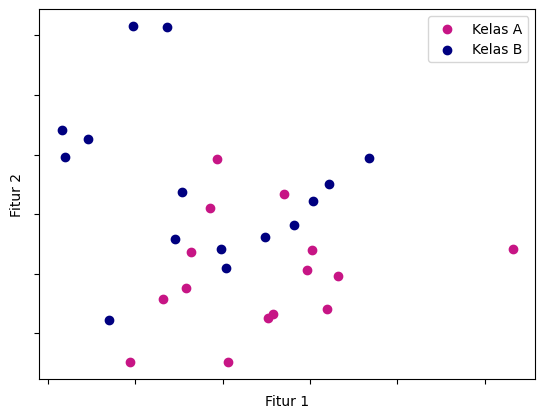

In [4]:
import matplotlib.pyplot as plt

# Definisikan warna untuk setiap kelas
colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

# Kelompokkan label berdasarkan nama kelas
gb = df_label.groupby('Label')
class_a = gb.get_group('Kelas A')
class_b = gb.get_group('Kelas B')

# Plot
plt.scatter(x=class_a['Fitur 1'], y=class_a['Fitur 2'], c=colors['class_a'])
plt.scatter(x=class_b['Fitur 1'], y=class_b['Fitur 2'], c=colors['class_b'])
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend(['Kelas A', 'Kelas B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

## Langkah 5 - Model Multinomial Naive Bayes
Model multinomial sejatinya digunakan untuk fitur **diskrit** (misalnya jumlah kata pada klasifikasi teks). Di sini model ini dicoba pada data kontinu **hanya sebagai pembelajaran**.

Langkah yang dilakukan: inisiasi model, split data (70% latih, 30% uji), fit, prediksi data latih dan uji, lalu hitung akurasi.

In [5]:
from sklearn.naive_bayes import MultinomialNB   # class untuk model MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score      # evaluasi model berdasarkan akurasi

# Inisiasi obyek MultinomialNB
mnb = MultinomialNB()

# Kita dapat langsung menggunakan fitur X dan label y
# hasil dari proses pembuatan data dummy

# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

# Fit model
# Label y harus dalam bentuk 1D atau (n_samples,)
mnb.fit(X_train, y_train)

# Prediksi dengan data training
y_train_pred = mnb.predict(X_train)

# Evaluasi akurasi training
acc_train = accuracy_score(y_train, y_train_pred)

# Prediksi test data
y_test_pred = mnb.predict(X_test)

# Evaluasi model dengan metric akurasi
acc_test = accuracy_score(y_test, y_test_pred)

# Print hasil evaluasi
print(f'Hasil akurasi data train: {acc_train}')
print(f'Hasil akurasi data test: {acc_test}')

Hasil akurasi data train: 0.6190476190476191
Hasil akurasi data test: 0.7777777777777778


## Langkah 6 - Model Gaussian Naive Bayes
Model Gaussian lebih cocok untuk data kontinu karena menggunakan distribusi Gaussian (normal). Split data yang digunakan **sama** dengan model multinomial agar perbandingannya adil.

In [6]:
from sklearn.naive_bayes import GaussianNB   # class untuk model GaussianNB

# Inisiasi obyek Gaussian
gnb = GaussianNB()

# Kita menggunakan split data training dan testing
# yang sama dengan model multinomial

# Fit model
# Label y harus dalam bentuk 1D atau (n_samples,)
gnb.fit(X_train, y_train)

# Prediksi dengan data training
y_train_pred_gnb = gnb.predict(X_train)

# Evaluasi akurasi training
acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

# Prediksi test data
y_test_pred_gnb = gnb.predict(X_test)

# Evaluasi model dengan metric akurasi
acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

# Print hasil evaluasi
print(f'Hasil akurasi data train (Gaussian): {acc_train_gnb}')
print(f'Hasil akurasi data test (Gaussian): {acc_test_gnb}')

Hasil akurasi data train (Gaussian): 0.6666666666666666
Hasil akurasi data test (Gaussian): 0.4444444444444444


### Perbandingan Ringkas
Tabel berikut merangkum hasil kedua model pada data dummy yang sama.

In [7]:
pd.DataFrame({
    'Model': ['Multinomial NB', 'Gaussian NB'],
    'Akurasi Train': [acc_train, acc_train_gnb],
    'Akurasi Test': [acc_test, acc_test_gnb],
})

,Model,Akurasi Train,Akurasi Test
0,Multinomial NB,0.619048,0.777778
1,Gaussian NB,0.666667,0.444444


## Kesimpulan Lab 2

| Model | Akurasi Train | Akurasi Test |
|---|---|---|
| Multinomial NB | 0.619 | 0.778 |
| Gaussian NB | 0.667 | 0.444 |

- Pada scatter plot (Langkah 4) kedua kelas **saling tumpang tindih** dan tidak terpisah jelas, sehingga kedua model hanya mencapai akurasi yang rendah sampai sedang.
- Secara teori **Gaussian NB lebih sesuai** untuk fitur kontinu, sedangkan Multinomial NB dirancang untuk fitur hasil penghitungan (diskrit). Meski begitu, pada percobaan ini Multinomial NB memberi akurasi uji lebih tinggi.
- Perbedaan tersebut **tidak bisa disimpulkan sebagai Multinomial lebih baik**: data uji hanya **9 sampel**, sehingga satu sampel saja mengubah akurasi sebesar 11.1%. Hasil ini sangat bergantung pada pembagian data dan data dummy yang dibangkitkan (coba ubah `random_state` untuk melihat variasinya).